In [1]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
from tensorflow import keras
import itertools
from skimage import io, feature
from sklearn.model_selection import train_test_split
from sklearn import svm
import matplotlib.pyplot as plt
import pickle
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tensorflow.keras.models import load_model
from skimage.measure import shannon_entropy
from PIL import Image
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from mpl_toolkits.mplot3d import Axes3D
from sklearn.svm import SVC
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense, Dropout,BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard

In [2]:
train_dir = "NEU Metal Surface Defects Data/train"
test_dir = "NEU Metal Surface Defects Data/test"
valid_dir = "NEU Metal Surface Defects Data/valid"

In [3]:
# Path to the folder containing images
image_folder = train_dir

# Initialize lists to store results
dimensions = []
aspect_ratios = []
pixel_intensities = []
entropies = []
edge_percentages = []

# Function to calculate edge percentage
def edge_percentage(image):
    edges = cv2.Canny(image, 100, 200)
    return np.sum(edges > 0) / edges.size

# Loop through images in the folder
for subfolder in os.listdir(image_folder):
    subfolder_path = os.path.join(image_folder, subfolder)
    if os.path.isdir(subfolder_path):
        for filename in os.listdir(subfolder_path):
            if filename.endswith((".bmp", ".jpg", ".png")):  # Supported formats
                file_path = os.path.join(subfolder_path, filename)

                # Read the image
                image = cv2.imread(file_path)
                if image is not None:
                    # Store dimensions
                    h, w, c = image.shape
                    dimensions.append((h, w, c))

                    # Calculate and store aspect ratio
                    aspect_ratios.append(w / h)

                    # Convert to grayscale
                    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

                    # Calculate and store mean pixel intensity
                    pixel_intensities.append(np.mean(gray_image))

                    # Calculate and store texture entropy
                    entropies.append(shannon_entropy(gray_image))

                    # Calculate and store edge percentage
                    edge_percentages.append(edge_percentage(gray_image))

# Convert to NumPy arrays for analysis
dimensions = np.array(dimensions)
aspect_ratios = np.array(aspect_ratios)
pixel_intensities = np.array(pixel_intensities)
entropies = np.array(entropies)
edge_percentages = np.array(edge_percentages)


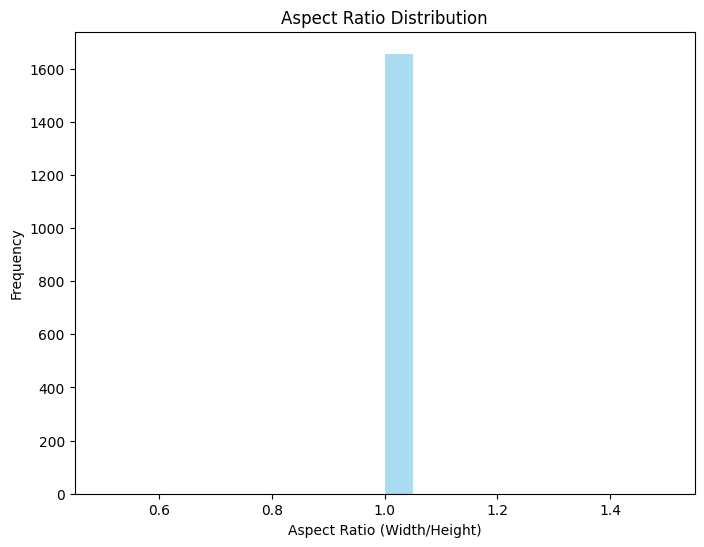

In [4]:
#  Aspect Ratios
plt.figure(figsize=(8, 6))
plt.hist(aspect_ratios, bins=20, color="skyblue", alpha=0.7)
plt.xlabel("Aspect Ratio (Width/Height)")
plt.ylabel("Frequency")
plt.title("Aspect Ratio Distribution")
plt.show()


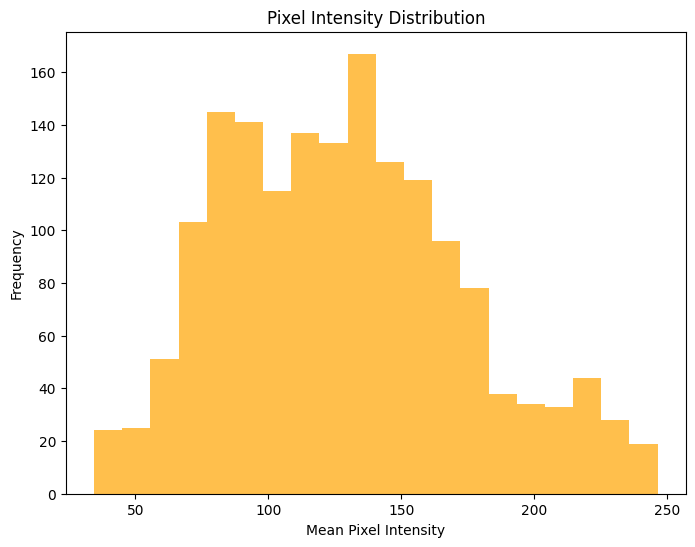

In [5]:
#  Pixel Intensity Distribution
plt.figure(figsize=(8, 6))
plt.hist(pixel_intensities, bins=20, color="orange", alpha=0.7)
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Pixel Intensity Distribution")
plt.show()

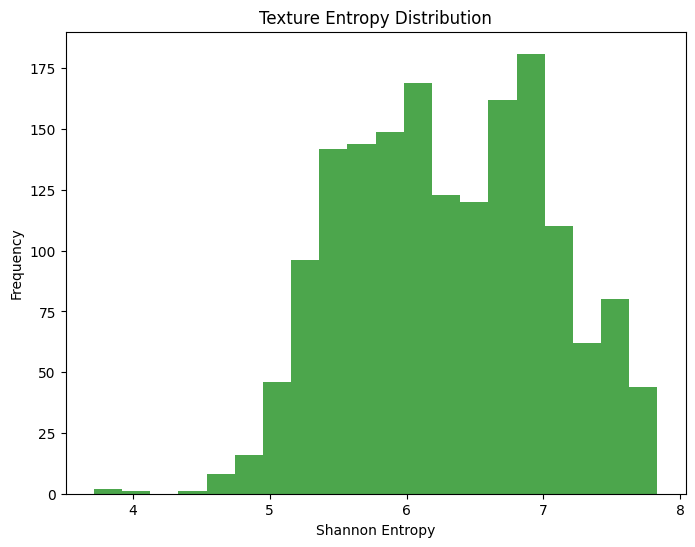

In [6]:
# Entropy (Texture Complexity)
plt.figure(figsize=(8, 6))
plt.hist(entropies, bins=20, color="green", alpha=0.7)
plt.xlabel("Shannon Entropy")
plt.ylabel("Frequency")
plt.title("Texture Entropy Distribution")
plt.show()

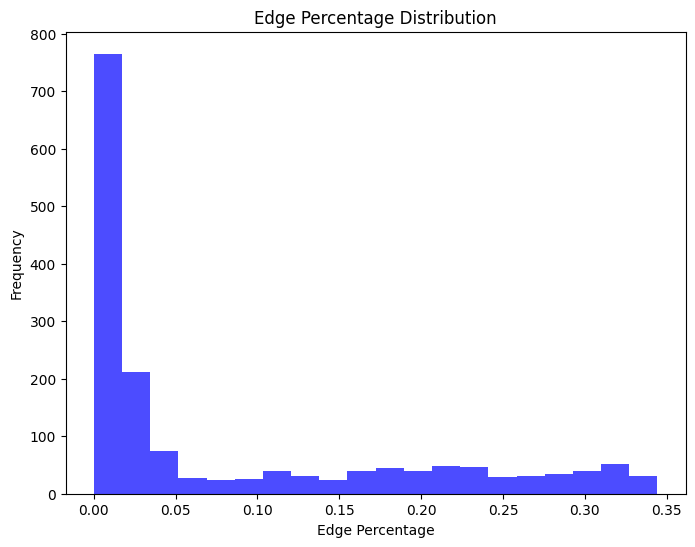

In [7]:
# Edge Percentage
plt.figure(figsize=(8, 6))
plt.hist(edge_percentages, bins=20, color="blue", alpha=0.7)
plt.xlabel("Edge Percentage")
plt.ylabel("Frequency")
plt.title("Edge Percentage Distribution")
plt.show()

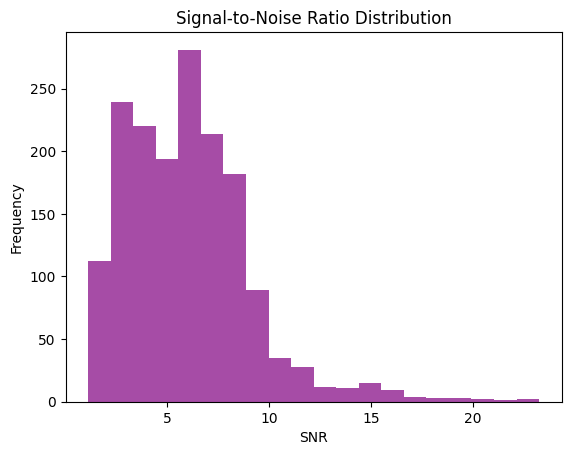

In [8]:
def calculate_snr(image):
    mean_signal = np.mean(image)
    noise = np.std(image)
    return mean_signal / noise

snr_values = []
for subfolder in os.listdir(image_folder):
    subfolder_path = os.path.join(image_folder, subfolder)
    if os.path.isdir(subfolder_path):
        for filename in os.listdir(subfolder_path):
            if filename.endswith((".bmp", ".jpg", ".png")):
                file_path = os.path.join(subfolder_path, filename)
                image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
                if image is not None:
                    snr_values.append(calculate_snr(image))

plt.hist(snr_values, bins=20, color='purple', alpha=0.7)
plt.title("Signal-to-Noise Ratio Distribution")
plt.xlabel("SNR")
plt.ylabel("Frequency")
plt.show()


In [9]:
train_datagen = ImageDataGenerator(rescale=1./255,
                             shear_range=0.2,
#                              zoom_range=0.2,
                             horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir,
                                              target_size=(200, 200),
                                              batch_size=36,
                                              class_mode='categorical',
                                                    shuffle = True
                                              )

valid_generator = test_datagen.flow_from_directory(valid_dir,
                                              target_size=(200, 200),
                                              batch_size=36,
                                              class_mode='categorical'
                                              )

test_generator = test_datagen.flow_from_directory(test_dir,
                                              target_size=(200, 200),
                                              batch_size=36,
                                              class_mode='categorical',
                                              shuffle = False
                                              )


Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.


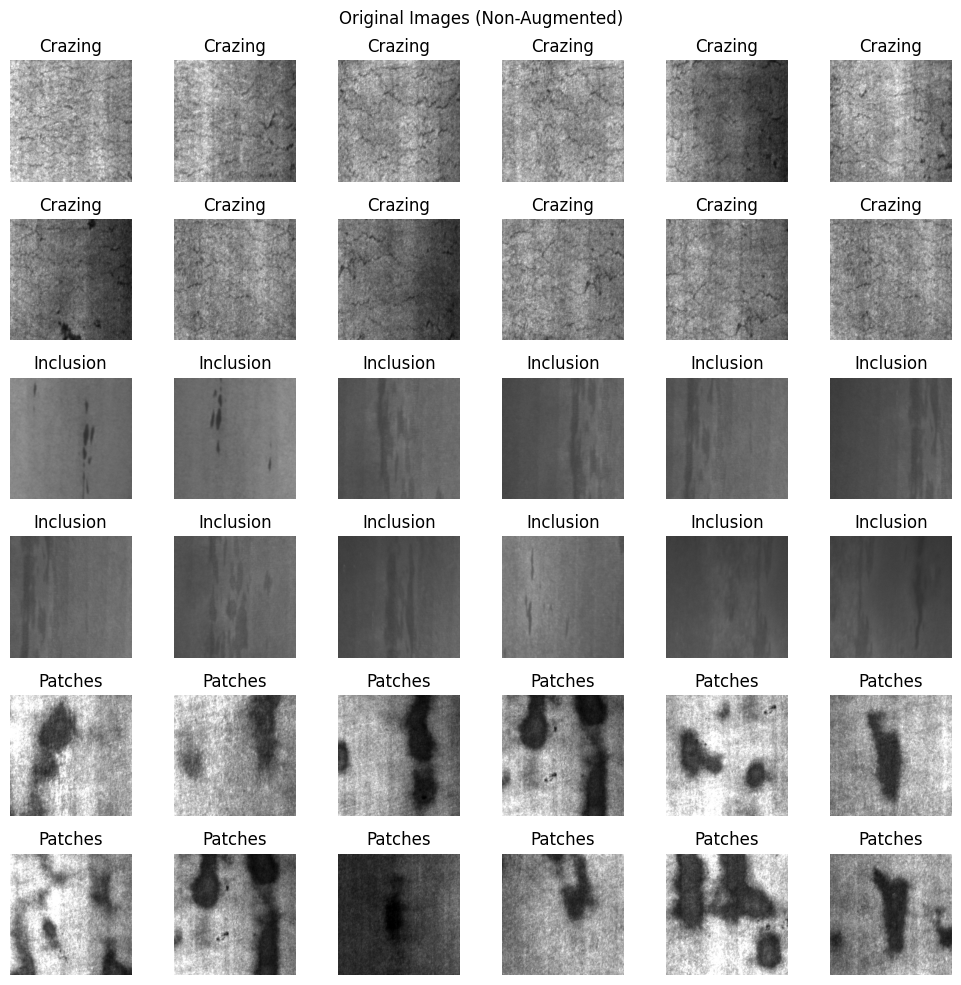

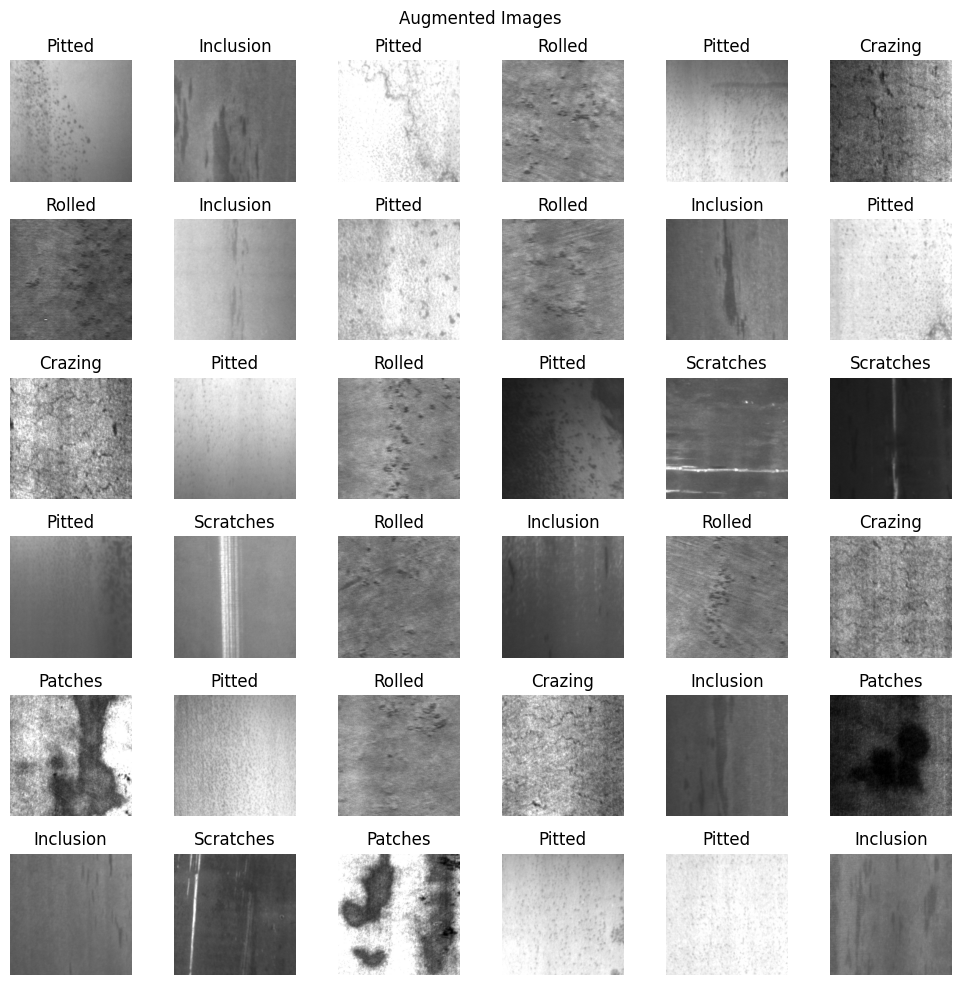

In [10]:
# Function to display images in a grid
def plot_images(images, labels, title, class_indices):
    plt.figure(figsize=(10, 10))
    for i in range(len(images)):
        plt.subplot(6, 6, i + 1)  # Adjust grid size if necessary
        plt.imshow(images[i])
        plt.title(class_indices[labels[i]])
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Plot original (non-augmented) images
original_images, original_labels = next(test_generator)  # Load a batch of original images
original_images = original_images[:36]  # Limit to 36 images
original_labels = np.argmax(original_labels[:36], axis=1)  # Decode one-hot labels
class_indices = {v: k for k, v in test_generator.class_indices.items()}  # Decode class indices

plot_images(
    original_images,
    original_labels,
    title="Original Images (Non-Augmented)",
    class_indices=class_indices
)

# Plot augmented images
augmented_images, augmented_labels = next(train_generator)  # Load a batch of augmented images
augmented_images = augmented_images[:36]  # Limit to 36 images
augmented_labels = np.argmax(augmented_labels[:36], axis=1)  # Decode one-hot labels

plot_images(
    augmented_images,
    augmented_labels,
    title="Augmented Images",
    class_indices=class_indices
)


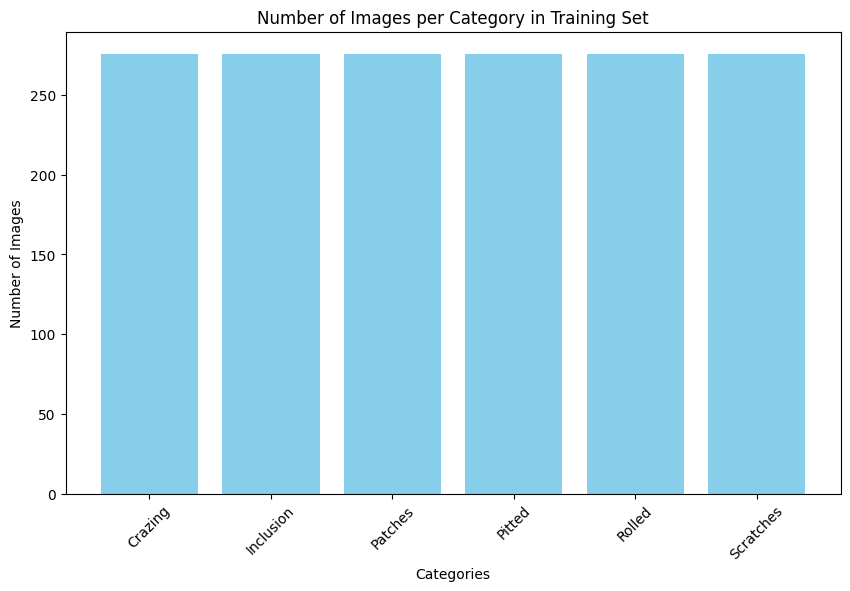

In [11]:
def count_images_per_category(directory):
    categories = os.listdir(directory)
    counts = Counter()
    
    for category in categories:
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            num_images = len(os.listdir(category_path))
            counts[category] = num_images
    
    return counts

# Count the images in each category for the training set
train_counts = count_images_per_category(train_dir)
plt.figure(figsize=(10, 6))
plt.bar(train_counts.keys(), train_counts.values(), color='skyblue')
plt.xlabel('Categories')
plt.ylabel('Number of Images')
plt.title('Number of Images per Category in Training Set')
plt.xticks(rotation=45)
plt.show()

In [12]:
for image_batch, labels_batch in train_generator:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(36, 200, 200, 3)
(36, 6)


In [13]:
def get_sample_image(generator):
    images, labels = next(generator)
    image = images[0]
    label_index = np.argmax(labels[0])
    class_names=list(train_generator.class_indices.keys())
    label_name = class_names[label_index]

    return image, label_name


def sample_images(generator, nrows=4, ncols=4):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 15))
    
    for i in range(nrows*ncols):
        image, label_name = get_sample_image(generator)
        row = i // ncols
        col = i % ncols
        ax = axes[row][col]
#         ax.imshow(image , cmap='gray_r')
        ax.imshow(image)
        ax.set_title(label_name)
        ax.axis('off')

    plt.show()

In [14]:
def extract_features(generator):
    features = []
    labels = []
    batches_processed = 0

    for inputs_batch, labels_batch in generator:
        features.append(inputs_batch)
        labels.append(labels_batch)
        batches_processed += 1
        
        # Check if all samples have been processed
        if batches_processed * generator.batch_size >= generator.samples:
            break

    # Stack features and labels
    features = np.vstack(features)
    labels = np.vstack(labels)
    
    print(f"Processed {batches_processed} batches.")
    print(f"Total features shape: {features.shape}")
    print(f"Total labels shape: {labels.shape}")
    
    return features, labels

# Extract features and labels from generators
train_features, train_labels = extract_features(train_generator)
validation_features, validation_labels = extract_features(valid_generator)
test_features, test_labels = extract_features(test_generator)

# Flatten the features for PCA and t-SNE
num_samples, height, width, channels = train_features.shape
flattened_features = train_features.reshape(num_samples, height * width * channels)

print(f"Shape of flattened_features: {flattened_features.shape}")
print(f"Shape of train_labels: {train_labels.shape}")

Processed 46 batches.
Total features shape: (1656, 200, 200, 3)
Total labels shape: (1656, 6)
Processed 2 batches.
Total features shape: (72, 200, 200, 3)
Total labels shape: (72, 6)
Processed 2 batches.
Total features shape: (72, 200, 200, 3)
Total labels shape: (72, 6)
Shape of flattened_features: (1656, 120000)
Shape of train_labels: (1656, 6)


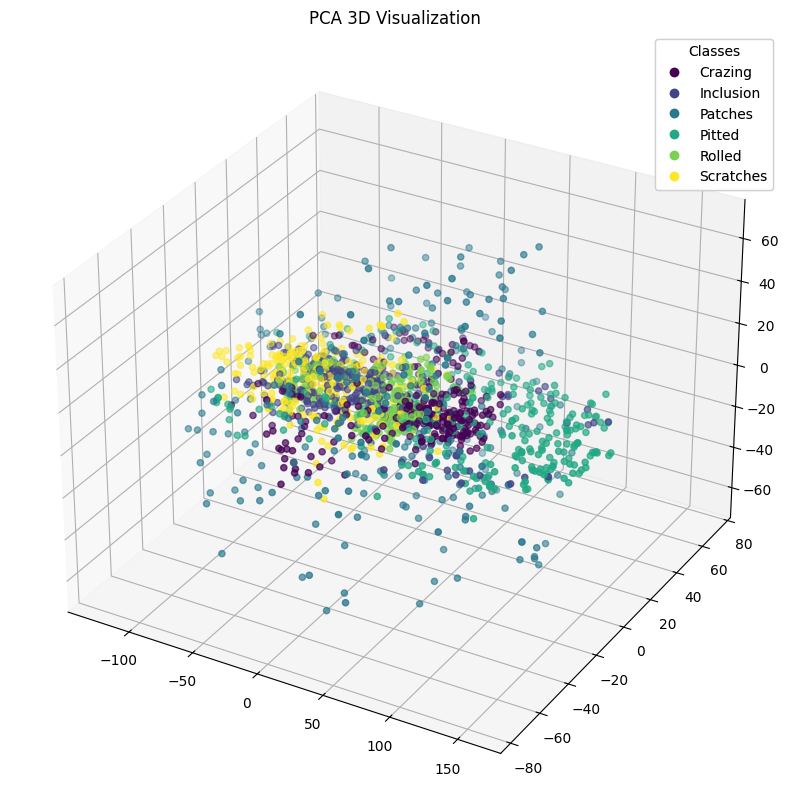

In [15]:
# PCA for 3D
class_names=list(train_generator.class_indices.keys())

pca = PCA(n_components=3)
reduced_features_3d = pca.fit_transform(flattened_features)

fig = plt.figure(figsize= (10,10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(reduced_features_3d[:, 0], reduced_features_3d[:, 1], reduced_features_3d[:, 2], c=np.argmax(train_labels, axis=1), cmap='viridis')
# legend = ax.legend(*scatter.legend_elements(), title="Classes")
# ax.add_artist(legend)
handles, _ = scatter.legend_elements()
legend = ax.legend(handles, class_names, title="Classes")
ax.add_artist(legend)
plt.title('PCA 3D Visualization')
plt.show()


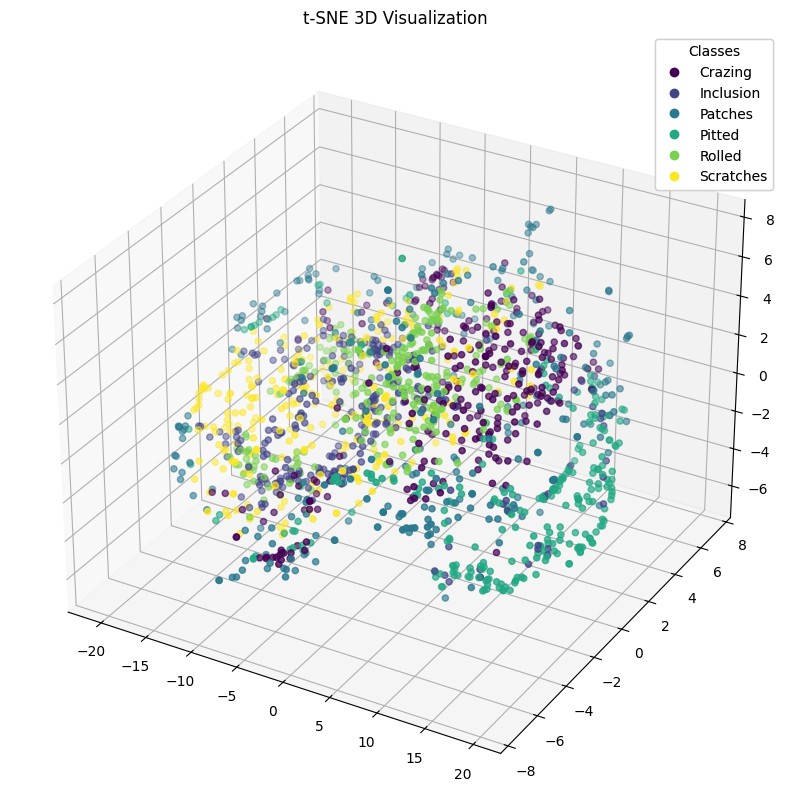

In [16]:
# t-SNE for 3D
tsne = TSNE(n_components=3, random_state=42)
tsne_features_3d = tsne.fit_transform(flattened_features)

fig = plt.figure(figsize= (10,10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(tsne_features_3d[:, 0], tsne_features_3d[:, 1], tsne_features_3d[:, 2], c=np.argmax(train_labels, axis=1), cmap='viridis')
# legend = ax.legend(*scatter.legend_elements(), title="Classes")
# ax.add_artist(legend)
handles, _ = scatter.legend_elements()
legend = ax.legend(handles, class_names, title="Classes")
ax.add_artist(legend)
plt.title('t-SNE 3D Visualization')
plt.show()

In [17]:
# Model layers
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
#     BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
#     BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
#     Dense(64, activation='relu'),
#     Dropout(0.3),
    Dense(6 ,activation='softmax')
])

C:\Users\ronan\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# Path to the folder containing images
from skimage.measure import shannon_entropy

image_folder = train_dir

# Initialize lists to store results
dimensions = []
aspect_ratios = []
pixel_intensities = []
entropies = []
edge_percentages = []

# Function to calculate edge percentage
def edge_percentage(image):
    edges = cv2.Canny(image, 100, 200)
    return np.sum(edges > 0) / edges.size

# Loop through images in the folder
for subfolder in os.listdir(image_folder):
    subfolder_path = os.path.join(image_folder, subfolder)
    if os.path.isdir(subfolder_path):
        for filename in os.listdir(subfolder_path):
            if filename.endswith((".bmp", ".jpg", ".png")):  # Supported formats
                file_path = os.path.join(subfolder_path, filename)

                # Read the image
                image = cv2.imread(file_path)
                if image is not None:
                    # Store dimensions
                    h, w, c = image.shape
                    dimensions.append((h, w, c))

                    # Calculate and store aspect ratio
                    aspect_ratios.append(w / h)

                    # Convert to grayscale
                    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

                    # Calculate and store mean pixel intensity
                    pixel_intensities.append(np.mean(gray_image))

                    # Calculate and store texture entropy
                    entropies.append(shannon_entropy(gray_image))

                    # Calculate and store edge percentage
                    edge_percentages.append(edge_percentage(gray_image))

# Convert to NumPy arrays for analysis
dimensions = np.array(dimensions)
aspect_ratios = np.array(aspect_ratios)
pixel_intensities = np.array(pixel_intensities)
entropies = np.array(entropies)
edge_percentages = np.array(edge_percentages)


In [19]:
IMG_SIZE = 128

def load_data(directory):
    data = []
    labels = []
    for idx, cls in enumerate(classes):
        cls_folder = os.path.join(directory, cls)
        for img_name in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0  # normalize
            data.append(img)
            labels.append(idx)
    return np.array(data), to_categorical(labels)

In [20]:
classes = os.listdir(test_dir)
print("Classes:", classes)

Classes: ['Crazing', 'Inclusion', 'Patches', 'Pitted', 'Rolled', 'Scratches']


In [21]:
from tensorflow.keras.utils import to_categorical

X_train, y_train = load_data(train_dir)
X_test, y_test = load_data(test_dir)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1656, 128, 128, 3)
Test shape: (72, 128, 128, 3)


# simple CNN

In [22]:
model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE,IMG_SIZE,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])


In [23]:
from tensorflow.keras.optimizers import Adam

model_cnn.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_cnn = model_cnn.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.1904 - loss: 1.9313 - val_accuracy: 0.4028 - val_loss: 1.4453
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.4389 - loss: 1.3376 - val_accuracy: 0.3889 - val_loss: 1.3775
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - accuracy: 0.6451 - loss: 0.9399 - val_accuracy: 0.6389 - val_loss: 1.0210
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.7065 - loss: 0.9080 - val_accuracy: 0.7083 - val_loss: 0.7392
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.7840 - loss: 0.6312 - val_accuracy: 0.7778 - val_loss: 0.7023
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.8012 - loss: 0.6148 - val_accuracy: 0.6944 - val_loss: 0.7535
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.8240 - loss: 0.5444 - val_accuracy: 0.8056 - val_loss: 0.4980
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.8657 - loss: 0.4245 - val_accuracy: 0.

In [24]:
# Evaluate
pred_cnn = model_cnn.predict(X_test)
print("Simple CNN Classification Report:")
print(classification_report(y_test.argmax(axis=1), pred_cnn.argmax(axis=1), target_names=classes))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Simple CNN Classification Report:
              precision    recall  f1-score   support

     Crazing       0.86      1.00      0.92        12
   Inclusion       0.67      0.33      0.44        12
     Patches       1.00      0.92      0.96        12
      Pitted       0.89      0.67      0.76        12
      Rolled       0.50      1.00      0.67        12
   Scratches       1.00      0.67      0.80        12

    accuracy                           0.76        72
   macro avg       0.82      0.76      0.76        72
weighted avg       0.82      0.76      0.76        72



# Model2: TRANSFER LEARNING (VGG16)

In [25]:
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications import VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(classes), activation='softmax')(x)


In [26]:
model_vgg = Model(inputs=base_model.input, outputs=output)
model_vgg.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_vgg = model_vgg.fit(preprocess_input(X_train), y_train, epochs=10, validation_data=(preprocess_input(X_test), y_test))


Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 50s 936ms/step - accuracy: 0.1811 - loss: 3.1785 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 49s 931ms/step - accuracy: 0.1694 - loss: 1.7919 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 48s 925ms/step - accuracy: 0.1602 - loss: 1.7919 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 48s 917ms/step - accuracy: 0.1814 - loss: 1.7918 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 48s 914ms/step - accuracy: 0.1608 - loss: 1.7918 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 48s 916ms/step - accuracy: 0.1618 - loss: 1.7919 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 48s 918ms/step - accuracy: 0.1357 - loss: 1.7919 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 49s 946ms/step - accuracy: 0.1860 - loss: 1.7918 - val_accu

In [27]:
# Evaluate
pred_vgg = model_vgg.predict(preprocess_input(X_test))
print("VGG16 Transfer Learning Classification Report:")
print(classification_report(y_test.argmax(axis=1), pred_vgg.argmax(axis=1), target_names=classes))


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 706ms/step
VGG16 Transfer Learning Classification Report:
              precision    recall  f1-score   support

     Crazing       0.00      0.00      0.00        12
   Inclusion       0.00      0.00      0.00        12
     Patches       0.00      0.00      0.00        12
      Pitted       0.17      1.00      0.29        12
      Rolled       0.00      0.00      0.00        12
   Scratches       0.00      0.00      0.00        12

    accuracy                           0.17        72
   macro avg       0.03      0.17      0.05        72
weighted avg       0.03      0.17      0.05        72



C:\Users\ronan\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ronan\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ronan\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

# model3: MLP BASELINE

In [28]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

model_mlp = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_flat.shape[1],)),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model_mlp.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
history_mlp = model_mlp.fit(X_train_flat, y_train, epochs=10, validation_data=(X_test_flat, y_test))


C:\Users\ronan\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.1854 - loss: 4397.1831 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.1689 - loss: 1.7918 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.1740 - loss: 1.7918 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.1739 - loss: 1.7918 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.1842 - loss: 1.7918 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.1534 - loss: 1.7918 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.1584 - loss: 1.7917 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.1574 - loss: 1.7918 - val_accuracy:

In [29]:
# Evaluate
pred_mlp = model_mlp.predict(X_test_flat)
print("MLP Baseline Classification Report:")
print(classification_report(y_test.argmax(axis=1), pred_mlp.argmax(axis=1), target_names=classes))


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000021AA92BC3A0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
MLP Baseline Classification Report:
              precision    recall  f1-score   support

     Crazing       0.17      1.00      0.29        12
   Inclusion       0.00      0.00      0.00        12


C:\Users\ronan\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ronan\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ronan\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [30]:
# Summarize accuracy from each model
acc_cnn = history_cnn.history['val_accuracy'][-1]
acc_vgg = history_vgg.history['val_accuracy'][-1]
acc_mlp = history_mlp.history['val_accuracy'][-1]

print("\nFinal Validation Accuracies:")
print(f"Simple CNN: {acc_cnn:.4f}")
print(f"VGG16 Transfer Learning: {acc_vgg:.4f}")
print(f"MLP Baseline: {acc_mlp:.4f}")

best_model = max([('Simple CNN', acc_cnn), ('VGG16', acc_vgg), ('MLP', acc_mlp)], key=lambda x: x[1])
print(f"\n✅ Best performing model: {best_model[0]} with accuracy of {best_model[1]:.4f}")



Final Validation Accuracies:
Simple CNN: 0.7639
VGG16 Transfer Learning: 0.1667
MLP Baseline: 0.1667

✅ Best performing model: Simple CNN with accuracy of 0.7639


In [31]:
# Initialize lists
entropies = []
edge_densities = []
means = []
stds = []

In [32]:
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Parameters for LBP
radius = 3
n_points = 8 * radius

In [33]:
X_feats = []
y_feats = []

for idx, cls in enumerate(classes):
    cls_folder = os.path.join(test_dir, cls)
    for img_name in os.listdir(cls_folder):
        img_path = os.path.join(cls_folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # LBP
        lbp = local_binary_pattern(img_resized, n_points, radius, method="uniform")
        (hist, _) = np.histogram(lbp.ravel(),
                                 bins=np.arange(0, n_points + 3),
                                 range=(0, n_points + 2))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)
        X_feats.append(hist)
        y_feats.append(idx)

In [34]:
X_feats = np.array(X_feats)
y_feats = np.array(y_feats)


In [35]:
# Split data
X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(X_feats, y_feats, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled = scaler.transform(X_test_feat)


# model4: SVM

In [36]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, y_train_feat)
svm_preds = svm_model.predict(X_test_scaled)


In [37]:
print("SVM Classification Report:")
print(classification_report(y_test_feat, svm_preds, target_names=classes))


SVM Classification Report:
              precision    recall  f1-score   support

     Crazing       1.00      1.00      1.00         5
   Inclusion       0.75      0.75      0.75         4
     Patches       1.00      1.00      1.00         4
      Pitted       1.00      1.00      1.00         3
      Rolled       1.00      1.00      1.00         5
   Scratches       0.00      0.00      0.00         1

    accuracy                           0.91        22
   macro avg       0.79      0.79      0.79        22
weighted avg       0.91      0.91      0.91        22



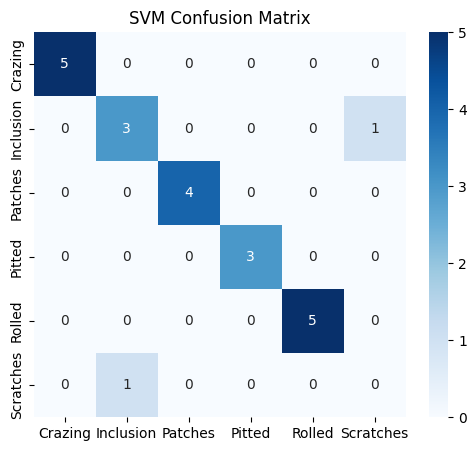

In [38]:
# Confusion Matrix
cm_svm = confusion_matrix(y_test_feat, svm_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("SVM Confusion Matrix")
plt.show()


In [39]:
# 📝 2.3 Train Random Forest
# -----------------------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_feat, y_train_feat)
rf_preds = rf_model.predict(X_test_feat)

print("Random Forest Classification Report:")
print(classification_report(y_test_feat, rf_preds, target_names=classes))


Random Forest Classification Report:
              precision    recall  f1-score   support

     Crazing       0.83      1.00      0.91         5
   Inclusion       0.80      1.00      0.89         4
     Patches       1.00      1.00      1.00         4
      Pitted       1.00      0.67      0.80         3
      Rolled       1.00      1.00      1.00         5
   Scratches       0.00      0.00      0.00         1

    accuracy                           0.91        22
   macro avg       0.77      0.78      0.77        22
weighted avg       0.88      0.91      0.89        22



C:\Users\ronan\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ronan\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ronan\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

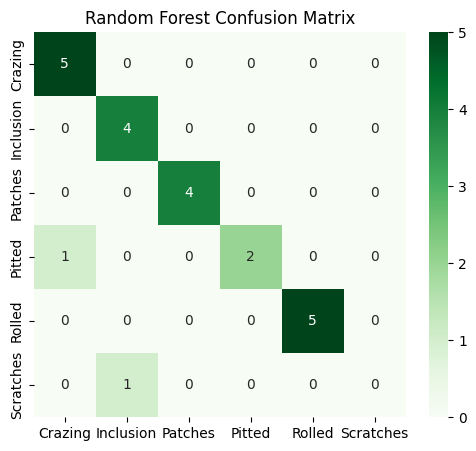

In [40]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test_feat, rf_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", xticklabels=classes, yticklabels=classes)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [41]:
# Plot training accuracy and loss curves for Simple CNN
plt.figure(figsize=(12,4))

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

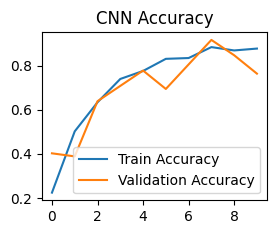

In [42]:
plt.subplot(2,2,2)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.legend()

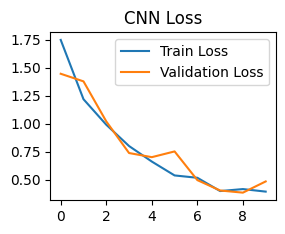

In [43]:
plt.subplot(2,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.legend()

plt.show()

In [49]:
import os
import numpy as np
import cv2
from skimage.measure import shannon_entropy
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score

# 1) Point to your dataset root folder
DATA_DIR = 'NEU Metal Surface Defects Data/valid'   # ← change this only if your folder has a different name

# 2) Extract features from each image
features = []
labels = []

print("Extracting features from images...")
for class_name in os.listdir(DATA_DIR):
    class_dir = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        img_path = os.path.join(class_dir, fname)
        img = cv2.imread(img_path)
        if img is None:
            continue
        # a) Aspect ratio (width / height)
        h, w = img.shape[:2]
        aspect_ratio = w / h
        # b) Mean pixel intensity (grayscale)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        mean_intensity = gray.mean()
        # c) Entropy (texture complexity)
        entropy = shannon_entropy(gray)
        # d) Edge percentage (Canny edges)
        edges = cv2.Canny(gray, 100, 200)
        edge_pct = edges.astype(bool).mean()
        # Append
        features.append([aspect_ratio, mean_intensity, entropy, edge_pct])
        labels.append(class_name)

# Convert to NumPy arrays
X = np.array(features)   # shape = (n_samples, 4)
le = LabelEncoder()
y = le.fit_transform(labels)  # shape = (n_samples,)

print(f"Feature matrix X shape: {X.shape}")
print(f"Label vector y shape:   {y.shape}")
print("Classes found:", list(le.classes_))

# 3) Define the SVM classifier
clf = SVC(kernel='linear', C=1.0, random_state=42)

# 4) Set up 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 5) Evaluate Accuracy
acc_scores = cross_val_score(estimator=clf,
                             X=X, y=y,
                             cv=kf,
                             scoring='accuracy')
print("\nAccuracy per fold: ", np.round(acc_scores, 3))
print(f"Mean accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")

# 6) Evaluate F1-score (macro average)
f1_macro = make_scorer(f1_score, average='macro')
f1_scores = cross_val_score(estimator=clf,
                            X=X, y=y,
                            cv=kf,
                            scoring=f1_macro)
print("F1-score per fold:", np.round(f1_scores, 3))
print(f"Mean F1-score: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")


Extracting features from images...
Feature matrix X shape: (72, 4)
Label vector y shape:   (72,)
Classes found: ['Crazing', 'Inclusion', 'Patches', 'Pitted', 'Rolled', 'Scratches']

Accuracy per fold:  [0.533 0.8   0.857 0.5   0.786]
Mean accuracy: 0.695 ± 0.148
F1-score per fold: [0.564 0.821 0.776 0.532 0.744]
Mean F1-score: 0.687 ± 0.117


In [50]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, f1_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2) Set up grid of hyperparameters
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

# 3) Define scoring
f1_macro = make_scorer(f1_score, average='macro')

# 4) Grid search with CV
grid = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    scoring={'Accuracy':'accuracy', 'F1':f1_macro},
    refit='F1',                 # choose best model by F1-score
    cv=skf,
    return_train_score=False,
    n_jobs=-1
)

grid.fit(X, y)

# 5) Results
print("Best parameters:", grid.best_params_)
print(f"Best cross-validated F1-score: {grid.best_score_:.3f}")

# 6) Per-fold performance for the best model
best_clf = grid.best_estimator_
acc_scores = cross_val_score(best_clf, X, y, cv=skf, scoring='accuracy')
f1_scores  = cross_val_score(best_clf, X, y, cv=skf, scoring=f1_macro)
print("Accuracy per fold:", np.round(acc_scores, 3))
print(f"Mean accuracy: {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
print("F1-score per fold:", np.round(f1_scores, 3))
print(f"Mean F1-score: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")


Best parameters: {'C': 100, 'kernel': 'linear'}
Best cross-validated F1-score: 0.837
Accuracy per fold: [0.867 0.8   0.857 0.786 1.   ]
Mean accuracy: 0.862 ± 0.076
F1-score per fold: [0.854 0.797 0.778 0.758 1.   ]
Mean F1-score: 0.837 ± 0.087


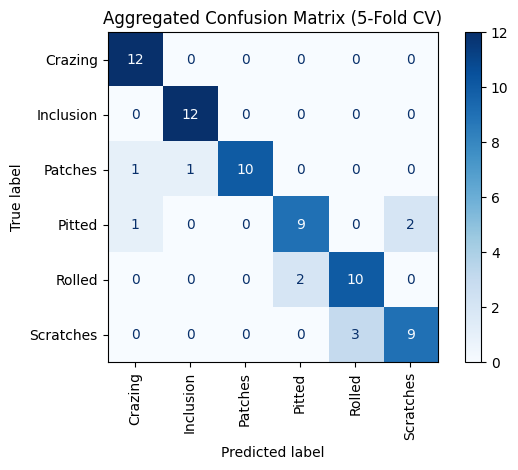

In [51]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assume X, y, and your best params are defined:
best_params = {'C': 100, 'kernel': 'linear', 'random_state': 42}
clf = SVC(**best_params)

# Stratified 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_true = []
all_pred = []

for train_idx, test_idx in skf.split(X, y):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    all_true.extend(y_te)
    all_pred.extend(y_pred)

all_true = np.array(all_true)
all_pred = np.array(all_pred)

# Compute & plot
cm = confusion_matrix(all_true, all_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Aggregated Confusion Matrix (5-Fold CV)")
plt.tight_layout()
plt.show()
